In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q timm

Imports

In [2]:
import gc
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("ResNet50 Cell 2 imports complete")

ResNet50 Cell 2 imports complete


Configuration and Seed

In [3]:
MODEL_NAME = "resnet50"

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

TOTAL_EPOCHS = 50
HEAD_EPOCHS = 5

HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
FINETUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

MODEL_DIR = Path("/kaggle/working/resnet50")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("AMP enabled:", USE_AMP)
print("Output directory:", MODEL_DIR)

Model: resnet50
Device: cuda
AMP enabled: True
Output directory: /kaggle/working/resnet50


Metadata and Image Path Load

In [4]:
INPUT_DIR = Path("/kaggle/input")

metadata_files = list(INPUT_DIR.rglob("HAM10000_metadata.csv"))

if not metadata_files:
    raise FileNotFoundError(
        
    )

metadata_path = metadata_files[0]
dataset_dir = metadata_path.parent

df = pd.read_csv(metadata_path)

image_paths = {}

for extension in ("*.jpg", "*.jpeg", "*.png"):
    for image_path in dataset_dir.rglob(extension):
        image_paths[image_path.stem] = str(image_path)

df["path"] = df["image_id"].map(image_paths)

print("Metadata path:", metadata_path)
print("Metadata rows:", len(df))
print("Images found:", len(image_paths))
print("Matched images:", df["path"].notna().sum())
print("Missing images:", df["path"].isna().sum())

df = df.dropna(subset=["path"]).reset_index(drop=True)

print("Final dataset size:", len(df))
display(df[["image_id", "dx", "lesion_id", "path"]].head())

Metadata path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Metadata rows: 10015
Images found: 10015
Matched images: 10015
Missing images: 0
Final dataset size: 10015


,image_id,dx,lesion_id,path
0,ISIC_0027419,bkl,HAM_0000118,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,HAM_0000118,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,HAM_0002730,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,HAM_0002730,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,HAM_0001466,/kaggle/input/datasets/kmader/skin-cancer-mnis...


Class Label Encoding

In [5]:
class_names = sorted(df["dx"].unique().tolist())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

df["label"] = df["dx"].map(class_to_idx).astype(int)

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Class mapping:", class_to_idx)
print("\nClass distribution:")
print(df["dx"].value_counts())

Number of classes: 7
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Lesion-Level Train, Validation and Test Split

In [7]:

splitter_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    splitter_1.split(
        df,
        groups=df["lesion_id"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)


splitter_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    splitter_2.split(
        temp_df,
        groups=temp_df["lesion_id"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)


train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTrain percentage:", round(len(train_df) / len(df) * 100, 2))
print("Validation percentage:", round(len(val_df) / len(df) * 100, 2))
print("Test percentage:", round(len(test_df) / len(df) * 100, 2))

print("\nLesion overlap: None")

Train images: 7002
Validation images: 1519
Test images: 1494

Train percentage: 69.92
Validation percentage: 15.17
Test percentage: 14.92

Lesion overlap: None


Image Augmentation and Transform

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.20,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Train augmentation created")
print("Validation and test transforms created")
print("Image size:", IMAGE_SIZE)

Train augmentation created
Validation and test transforms created
Image size: 224


Custom Dataset Class

In [9]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = int(row["label"])

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as error:
            raise RuntimeError(
                
            ) from error

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=val_test_transform
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=val_test_transform
)

sample_image, sample_label = train_dataset[0]

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))
print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Sample class:", idx_to_class[sample_label])

Train dataset: 7002
Validation dataset: 1519
Test dataset: 1494
Sample image shape: torch.Size([3, 224, 224])
Sample label: 2
Sample class: bkl


DataLoader, Class Weight and Split Save

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP
)


class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

class_weights = np.sqrt(
    len(train_df) / (NUM_CLASSES * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)


train_df.to_csv(MODEL_DIR / "train_split.csv", index=False)
val_df.to_csv(MODEL_DIR / "validation_split.csv", index=False)
test_df.to_csv(MODEL_DIR / "test_split.csv", index=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nClass counts:")
print(class_counts)

print("\nClass weights:")
for index, weight in enumerate(class_weights.detach().cpu().numpy()):
    print(f"{idx_to_class[index]}: {weight:.4f}")

print("\nDataLoaders, loss function and split files ready")

Train batches: 438
Validation batches: 95
Test batches: 94

Class counts:
label
0     207
1     381
2     741
3      89
4     770
5    4718
6      96
Name: count, dtype: int64

Class weights:
akiec: 2.1982
bcc: 1.6203
bkl: 1.1619
df: 3.3525
mel: 1.1398
nv: 0.4605
vasc: 3.2279

DataLoaders, loss function and split files ready


Creating Pretrained Model

In [11]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model:", MODEL_NAME)
print("Number of classes:", NUM_CLASSES)
print("Classifier:", model.get_classifier())
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print("Model device:", next(model.parameters()).device)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model: resnet50
Number of classes: 7
Classifier: Linear(in_features=2048, out_features=7, bias=True)
Total parameters: 23,522,375
Trainable parameters: 23,522,375
Model device: cuda:0


Backbone Freeze for first 5 Epoch

In [12]:

for parameter in model.parameters():
    parameter.requires_grad = False


classifier = model.get_classifier()

for parameter in classifier.parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=HEAD_EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Training phase: Classifier head only")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print("Head learning rate:", optimizer.param_groups[0]["lr"])
print("AMP scaler enabled:", scaler.is_enabled())

Training phase: Classifier head only
Total parameters: 23,522,375
Trainable parameters: 14,343
Head learning rate: 0.001
AMP scaler enabled: True


Training and Evaluation Functions

In [13]:
from tqdm.auto import tqdm


def train_one_epoch(model, data_loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        all_targets.extend(
            labels.detach().cpu().numpy()
        )
        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(data_loader.dataset)

    epoch_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1


@torch.no_grad()
def evaluate_model(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Evaluating",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )
        predictions = probabilities.argmax(dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        all_targets.extend(
            labels.detach().cpu().numpy()
        )
        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(data_loader.dataset)

    epoch_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "f1": epoch_f1,
        "targets": np.array(all_targets),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(all_probabilities)
    }


print("Training and evaluation functions ready")

Training and evaluation functions ready


50 Epoch Training, Fine-Tuning and Auto resume

In [15]:
BEST_MODEL_PATH = MODEL_DIR / "resnet50_best_model.pth"
LAST_CHECKPOINT_PATH = MODEL_DIR / "resnet50_last_checkpoint.pth"
HISTORY_PATH = MODEL_DIR / "training_history.csv"


def setup_head_training():
   
    for parameter in model.parameters():
        parameter.requires_grad = False

    
    classifier = model.get_classifier()

    for parameter in classifier.parameters():
        parameter.requires_grad = True

    new_optimizer = torch.optim.AdamW(
        classifier.parameters(),
        lr=HEAD_LR,
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        new_optimizer,
        T_max=HEAD_EPOCHS
    )

    return new_optimizer, new_scheduler


def setup_fine_tuning():
    
    for parameter in model.parameters():
        parameter.requires_grad = True

    classifier = model.get_classifier()

    classifier_parameter_ids = {
        id(parameter)
        for parameter in classifier.parameters()
    }

    backbone_parameters = [
        parameter
        for parameter in model.parameters()
        if id(parameter) not in classifier_parameter_ids
    ]

    
    new_optimizer = torch.optim.AdamW(
        [
            {
                "params": backbone_parameters,
                "lr": BACKBONE_LR
            },
            {
                "params": classifier.parameters(),
                "lr": FINETUNE_HEAD_LR
            }
        ],
        weight_decay=WEIGHT_DECAY
    )

    new_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        new_optimizer,
        T_max=TOTAL_EPOCHS - HEAD_EPOCHS
    )

    return new_optimizer, new_scheduler


history = {
    "epoch": [],
    "phase": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "backbone_lr": [],
    "head_lr": []
}

start_epoch = 1
best_val_f1 = -1.0

optimizer, scheduler = setup_head_training()



if LAST_CHECKPOINT_PATH.exists():
    print("Existing checkpoint found. Resuming training...")

    try:
        checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location=DEVICE,
            weights_only=False
        )
    except TypeError:
        checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location=DEVICE
        )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    completed_epoch = checkpoint["epoch"]
    start_epoch = completed_epoch + 1

    best_val_f1 = checkpoint.get(
        "best_val_f1",
        -1.0
    )

    history = checkpoint.get(
        "history",
        history
    )

    saved_phase = checkpoint.get(
        "phase",
        "head" if completed_epoch <= HEAD_EPOCHS else "fine_tuning"
    )

    
    if start_epoch <= HEAD_EPOCHS:
        optimizer, scheduler = setup_head_training()
        current_phase = "head"
    else:
        optimizer, scheduler = setup_fine_tuning()
        current_phase = "fine_tuning"

    
    if saved_phase == current_phase:
        try:
            optimizer.load_state_dict(
                checkpoint["optimizer_state_dict"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler_state_dict"]
            )

        except Exception as error:
            print(
                "Optimizer or scheduler state could not be restored:",
                error
            )

    
    if "scaler_state_dict" in checkpoint:
        try:
            scaler.load_state_dict(
                checkpoint["scaler_state_dict"]
            )
        except Exception:
            pass

    print("Resume epoch:", start_epoch)
    print("Previous best validation Macro F1:", best_val_f1)

else:
    print("Starting a new ResNet50 training session.")


if start_epoch > TOTAL_EPOCHS:
    print("Training has already completed 50 epochs.")

else:
    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):

        
        if epoch == HEAD_EPOCHS + 1:
            print("\nUnfreezing the backbone...")
            optimizer, scheduler = setup_fine_tuning()
            print("Full fine-tuning has started.")

        phase = (
            "head"
            if epoch <= HEAD_EPOCHS
            else "fine_tuning"
        )

        print("\n" + "=" * 70)
        print(
            f"Epoch {epoch}/{TOTAL_EPOCHS} | "
            f"Phase: {phase}"
        )
        print("=" * 70)

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        validation_results = evaluate_model(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )

        scheduler.step()

        if phase == "head":
            backbone_lr = 0.0
            head_lr = optimizer.param_groups[0]["lr"]
        else:
            backbone_lr = optimizer.param_groups[0]["lr"]
            head_lr = optimizer.param_groups[1]["lr"]

        history["epoch"].append(epoch)
        history["phase"].append(phase)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(
            validation_results["loss"]
        )
        history["val_accuracy"].append(
            validation_results["accuracy"]
        )
        history["val_f1"].append(
            validation_results["f1"]
        )
        history["backbone_lr"].append(backbone_lr)
        history["head_lr"].append(head_lr)

        # Save training history after every epoch
        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False
        )

        
        if validation_results["f1"] > best_val_f1:
            best_val_f1 = validation_results["f1"]

            torch.save(
                model.state_dict(),
                BEST_MODEL_PATH
            )

            print(
                f"New best model saved. "
                f"Validation Macro F1: {best_val_f1:.4f}"
            )

        
        checkpoint = {
            "epoch": epoch,
            "phase": phase,
            "model_name": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "class_names": class_names,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_f1": best_val_f1,
            "history": history
        }

        torch.save(
            checkpoint,
            LAST_CHECKPOINT_PATH
        )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Train Macro F1: {train_f1:.4f}"
        )

        print(
            f"Validation Loss: {validation_results['loss']:.4f} | "
            f"Validation Accuracy: {validation_results['accuracy']:.4f} | "
            f"Validation Macro F1: {validation_results['f1']:.4f}"
        )

        print(f"Checkpoint saved after epoch {epoch}")

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nResNet50 training completed.")
    print("Best validation Macro F1:", best_val_f1)
    print("Best model path:", BEST_MODEL_PATH)
    print("Last checkpoint path:", LAST_CHECKPOINT_PATH)

Starting a new ResNet50 training session.

Epoch 1/50 | Phase: head


Training:   0%|          | 0/438 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

New best model saved. Validation Macro F1: 0.3817
Train Loss: 1.9516 | Train Accuracy: 0.6819 | Train Macro F1: 0.2345
Validation Loss: 1.8337 | Validation Accuracy: 0.7215 | Validation Macro F1: 0.3817
Checkpoint saved after epoch 1

Epoch 2/50 | Phase: head


Training:   0%|          | 0/438 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 1.4728 | Train Accuracy: 0.7911 | Train Macro F1: 0.6413
Validation Loss: 1.6425 | Validation Accuracy: 0.7650 | Validation Macro F1: 0.5657
Checkpoint saved after epoch 49

Epoch 50/50 | Phase: fine_tuning


Training:   0%|          | 0/438 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/95 [00:00<?, ?it/s]

Train Loss: 1.4821 | Train Accuracy: 0.7936 | Train Macro F1: 0.6520
Validation Loss: 1.6460 | Validation Accuracy: 0.7637 | Validation Macro F1: 0.5587
Checkpoint saved after epoch 50

ResNet50 training completed.
Best validation Macro F1: 0.588045133246341
Best model path: /kaggle/working/resnet50/resnet50_best_model.pth
Last checkpoint path: /kaggle/working/resnet50/resnet50_last_checkpoint.pth


Load the Best Model and Evaluate on the Test Set

In [16]:
import json


try:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=True
    )
except TypeError:
    best_state_dict = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )

model.load_state_dict(best_state_dict)
model = model.to(DEVICE)

print("Best ResNet50 model loaded successfully.")


test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion
)

test_targets = test_results["targets"]
test_predictions = test_results["predictions"]
test_probabilities = test_results["probabilities"]


test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

macro_precision = precision_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)


try:
    macro_roc_auc = roc_auc_score(
        test_targets,
        test_probabilities,
        multi_class="ovr",
        average="macro",
        labels=np.arange(NUM_CLASSES)
    )
except ValueError as error:
    macro_roc_auc = np.nan
    print("ROC-AUC could not be calculated:", error)

test_metrics = {
    "model": MODEL_NAME,
    "test_loss": float(test_results["loss"]),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "macro_roc_auc_ovr": (
        None if np.isnan(macro_roc_auc)
        else float(macro_roc_auc)
    )
}


metrics_df = pd.DataFrame([test_metrics])
metrics_df.to_csv(
    MODEL_DIR / "test_metrics.csv",
    index=False
)

with open(
    MODEL_DIR / "test_metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        test_metrics,
        file,
        indent=4
    )


report_text = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    MODEL_DIR / "classification_report.csv"
)

with open(
    MODEL_DIR / "classification_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)


prediction_df = test_df[
    ["image_id", "lesion_id", "dx", "label", "path"]
].copy()

prediction_df["true_class"] = [
    idx_to_class[index]
    for index in test_targets
]

prediction_df["predicted_label"] = test_predictions

prediction_df["predicted_class"] = [
    idx_to_class[index]
    for index in test_predictions
]

prediction_df["confidence"] = test_probabilities.max(axis=1)

for class_index, class_name in enumerate(class_names):
    prediction_df[f"probability_{class_name}"] = (
        test_probabilities[:, class_index]
    )

prediction_df.to_csv(
    MODEL_DIR / "test_predictions.csv",
    index=False
)

print("\nTest Results")
print("=" * 60)

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

print("\nClassification Report")
print("=" * 60)
print(report_text)

print("Test metrics, reports, and predictions saved successfully.")

Best ResNet50 model loaded successfully.


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

ROC-AUC could not be calculated: Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes

Test Results
model: resnet50
test_loss: 1.6306
test_accuracy: 0.7851
macro_precision: 0.5672
macro_recall: 0.6918
macro_f1: 0.5887
weighted_precision: 0.7963
weighted_recall: 0.7851
weighted_f1: 0.7805
macro_roc_auc_ovr: None

Classification Report
              precision    recall  f1-score   support

       akiec     0.4038    0.6667    0.5030        63
         bcc     0.4574    0.6324    0.5309        68
         bkl     0.7423    0.4737    0.5783       152
          df     0.3000    0.8571    0.4444         7
         mel     0.6316    0.3850    0.4784       187
          nv     0.8922    0.9227    0.9072       996
        vasc     0.5429    0.9048    0.6786        21

    accuracy                         0.7851      1494
   macro avg     0.5672    0.6918    0.5887      1494
weighted avg     0.7963    0.7851    0.7805      1494

Test metrics,

Training Curves and Confusion Matrix

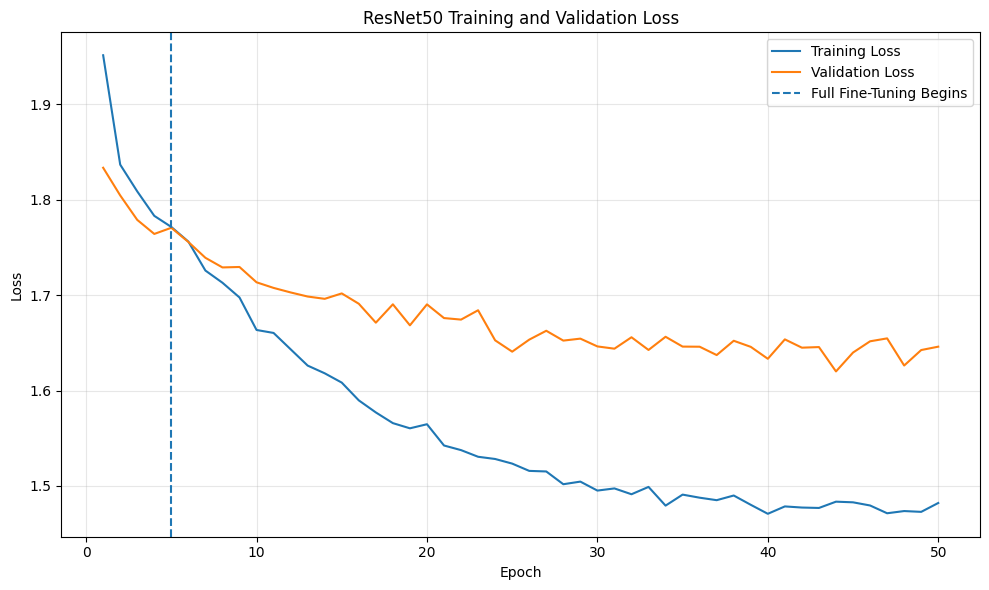

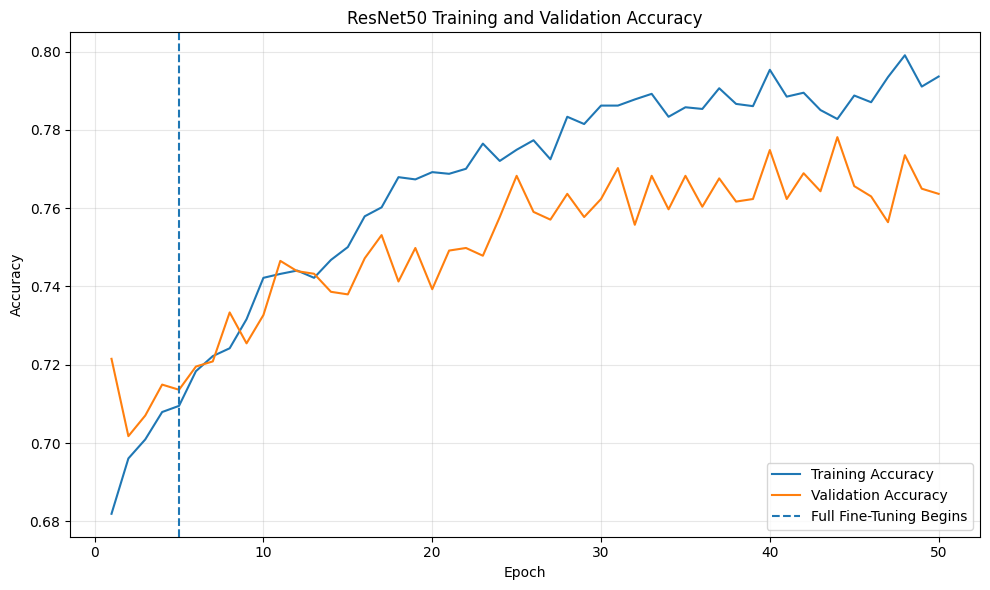

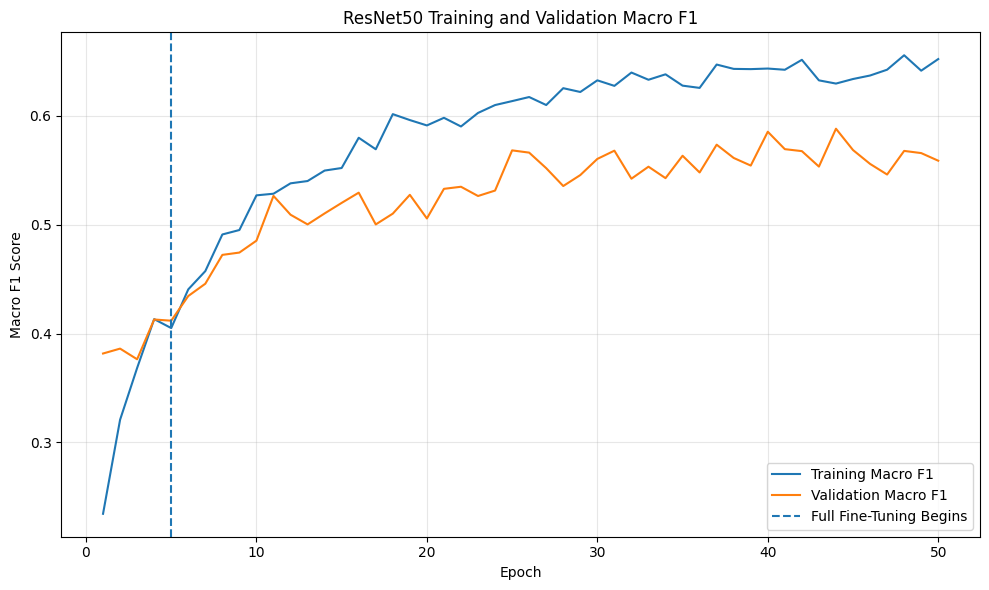

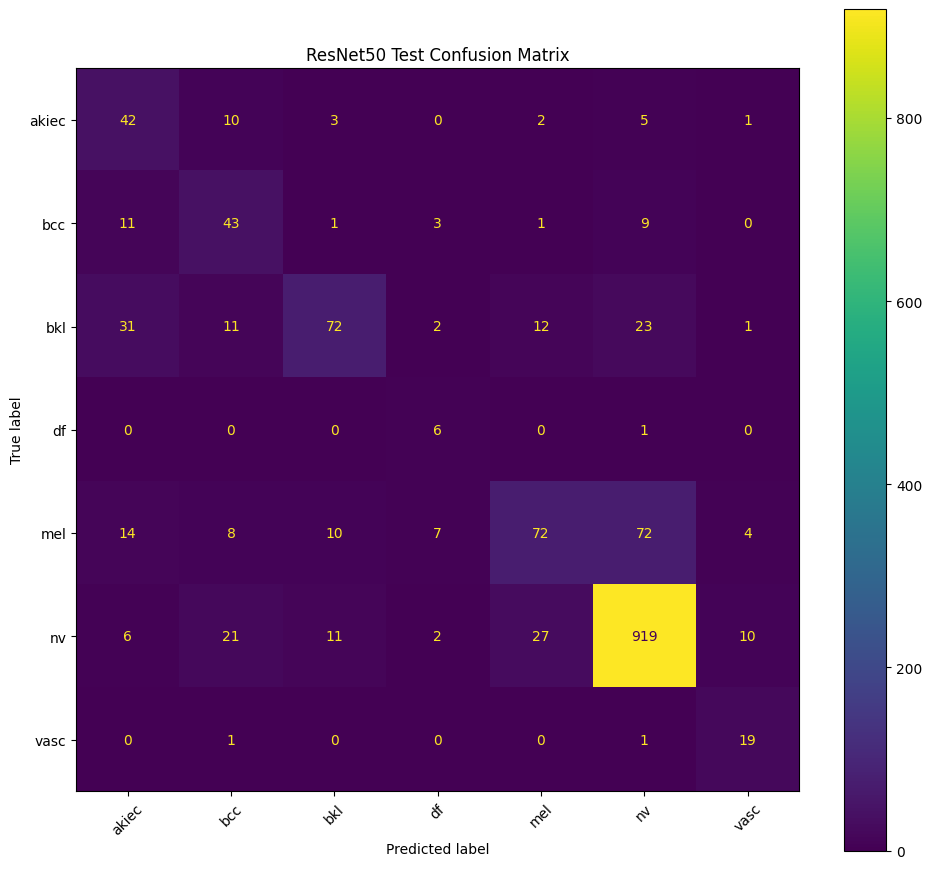

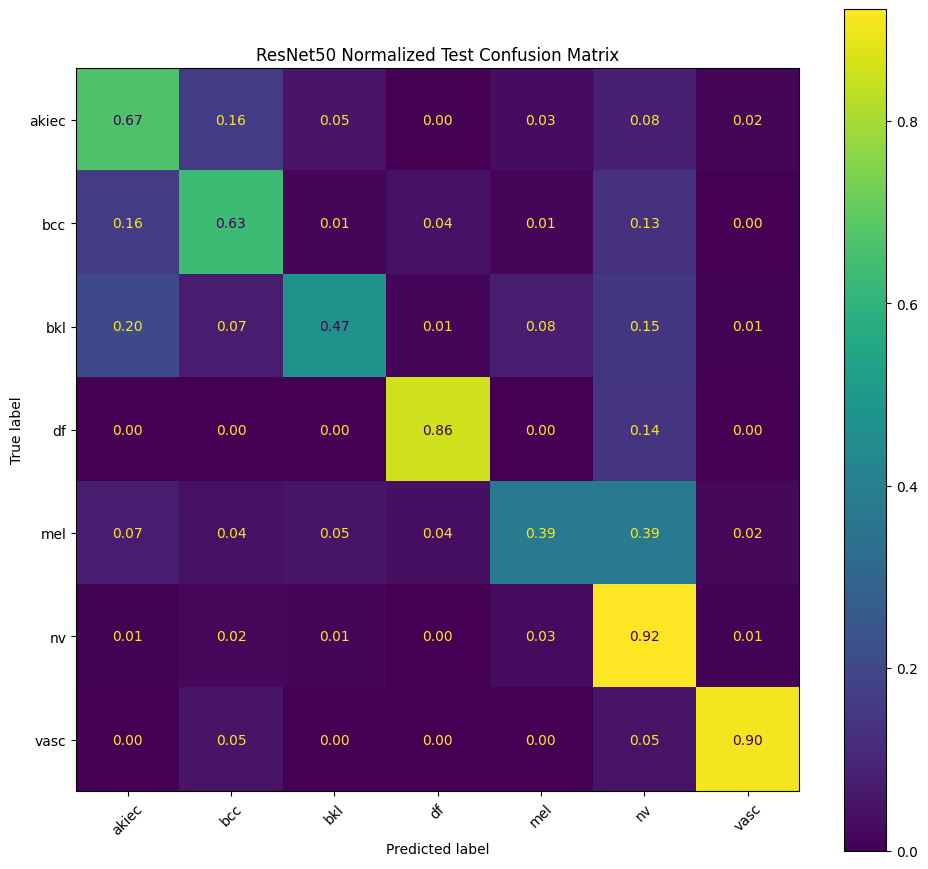

All plots were created and saved successfully.
Loss curve: /kaggle/working/resnet50/loss_curve.png
Accuracy curve: /kaggle/working/resnet50/accuracy_curve.png
Macro F1 curve: /kaggle/working/resnet50/macro_f1_curve.png
Confusion matrix: /kaggle/working/resnet50/confusion_matrix.png
Normalized confusion matrix: /kaggle/working/resnet50/normalized_confusion_matrix.png


In [17]:

history_df = pd.read_csv(HISTORY_PATH)

plt.ioff()



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

ax.axvline(
    x=HEAD_EPOCHS,
    linestyle="--",
    label="Full Fine-Tuning Begins"
)

ax.set_title("ResNet50 Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

loss_plot_path = MODEL_DIR / "loss_curve.png"

fig.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

ax.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

ax.axvline(
    x=HEAD_EPOCHS,
    linestyle="--",
    label="Full Fine-Tuning Begins"
)

ax.set_title("ResNet50 Training and Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

accuracy_plot_path = MODEL_DIR / "accuracy_curve.png"

fig.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["train_f1"],
    label="Training Macro F1"
)

ax.plot(
    history_df["epoch"],
    history_df["val_f1"],
    label="Validation Macro F1"
)

ax.axvline(
    x=HEAD_EPOCHS,
    linestyle="--",
    label="Full Fine-Tuning Begins"
)

ax.set_title("ResNet50 Training and Validation Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1 Score")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

f1_plot_path = MODEL_DIR / "macro_f1_curve.png"

fig.savefig(
    f1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 9))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    display_labels=class_names,
    normalize=None,
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("ResNet50 Test Confusion Matrix")

fig.tight_layout()

confusion_matrix_path = MODEL_DIR / "confusion_matrix.png"

fig.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(figsize=(10, 9))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    display_labels=class_names,
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("ResNet50 Normalized Test Confusion Matrix")

fig.tight_layout()

normalized_confusion_matrix_path = (
    MODEL_DIR / "normalized_confusion_matrix.png"
)

fig.savefig(
    normalized_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


print("All plots were created and saved successfully.")
print("Loss curve:", loss_plot_path)
print("Accuracy curve:", accuracy_plot_path)
print("Macro F1 curve:", f1_plot_path)
print("Confusion matrix:", confusion_matrix_path)
print(
    "Normalized confusion matrix:",
    normalized_confusion_matrix_path
)

Create the Final Results ZIP

In [18]:
FINAL_ZIP_BASE = "/kaggle/working/resnet50_HAM10000_results"
FINAL_ZIP_PATH = Path(FINAL_ZIP_BASE + ".zip")


if FINAL_ZIP_PATH.exists():
    FINAL_ZIP_PATH.unlink()


expected_files = [
    "resnet50_best_model.pth",
    "resnet50_last_checkpoint.pth",
    "training_history.csv",
    "test_metrics.csv",
    "test_metrics.json",
    "classification_report.csv",
    "classification_report.txt",
    "test_predictions.csv",
    "train_split.csv",
    "validation_split.csv",
    "test_split.csv",
    "loss_curve.png",
    "accuracy_curve.png",
    "macro_f1_curve.png",
    "confusion_matrix.png",
    "normalized_confusion_matrix.png"
]

print("Output file verification")
print("=" * 60)

missing_files = []

for file_name in expected_files:
    file_path = MODEL_DIR / file_name

    if file_path.exists():
        print(f"FOUND: {file_name}")
    else:
        print(f"MISSING: {file_name}")
        missing_files.append(file_name)


created_zip = shutil.make_archive(
    base_name=FINAL_ZIP_BASE,
    format="zip",
    root_dir=MODEL_DIR
)

zip_size_mb = Path(created_zip).stat().st_size / (1024 ** 2)

print("\n" + "=" * 60)
print("Final ZIP created successfully")
print("ZIP path:", created_zip)
print(f"ZIP size: {zip_size_mb:.2f} MB")

if missing_files:
    print("\nWarning: These expected files were not included:")
    for file_name in missing_files:
        print("-", file_name)
else:
    print("\nAll expected ResNet50 files are included.")

Output file verification
FOUND: resnet50_best_model.pth
FOUND: resnet50_last_checkpoint.pth
FOUND: training_history.csv
FOUND: test_metrics.csv
FOUND: test_metrics.json
FOUND: classification_report.csv
FOUND: classification_report.txt
FOUND: test_predictions.csv
FOUND: train_split.csv
FOUND: validation_split.csv
FOUND: test_split.csv
FOUND: loss_curve.png
FOUND: accuracy_curve.png
FOUND: macro_f1_curve.png
FOUND: confusion_matrix.png
FOUND: normalized_confusion_matrix.png

Final ZIP created successfully
ZIP path: /kaggle/working/resnet50_HAM10000_results.zip
ZIP size: 332.84 MB

All expected ResNet50 files are included.
